# Part 2 — RFM Segmentation & Retention Strategy
**Snapshot date:** `2025-09-30` | Universe: 2,400 customers

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR      = Path('../data')
OUTPUT_DIR    = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
SNAPSHOT_DATE = pd.Timestamp('2025-09-30')
TOTAL_BUDGET  = 50_000   # INR

SEG_COLORS = {
    'Champions':           '#27ae60',
    'Loyal Customers':     '#2980b9',
    'Promising Risers':    '#8e44ad',
    'At-Risk Customers':   '#e67e22',
    'Discount Dependents': '#f39c12',
    'Dormant Customers':   '#c0392b',
}
print('Ready.')

Ready.


## 1. Load Data

**Theory — Why all-history RFM for segmentation?**  
The `rfm_modeling_snapshot.csv` caps at 180 days. For *segmentation* (Part 2) we want to understand the customer's full relationship with the brand — a customer who spent ₹20,000 over 2 years but nothing in the last 180 days deserves a different segment than a truly new customer. For *modelling* (Part 3) we use the 180-day window to prevent signal mixing across different customer tenures.

In [20]:
customers = pd.read_csv(DATA_DIR / 'customers.csv',           parse_dates=['signup_date'])
orders    = pd.read_csv(DATA_DIR / 'orders.csv',              parse_dates=['order_date'])
tickets   = pd.read_csv(DATA_DIR / 'support_tickets.csv',     parse_dates=['ticket_date'])
web       = pd.read_csv(DATA_DIR / 'web_events_snapshot.csv', parse_dates=['snapshot_date'])
labels    = pd.read_csv(DATA_DIR / 'churn_labels.csv',        parse_dates=['snapshot_date'])
interv    = pd.read_csv(DATA_DIR / 'intervention_history.csv',parse_dates=['snapshot_date'])

orders_clean = orders[~orders['order_id'].str.endswith('_DUP', na=False)].copy()
orders_pre   = orders_clean[orders_clean['order_date'] <= SNAPSHOT_DATE].copy()

print(f'Customers : {len(customers):,}')
print(f'Orders (pre-snapshot) : {len(orders_pre):,}')

Customers : 2,400
Orders (pre-snapshot) : 8,128


## 2. Build RFM Features

**Theory — What each dimension captures**

| Metric | Definition | Business meaning |
|---|---|---|
| **Recency (R)** | Days since last order from snapshot | Purchase recency proxies for relationship strength. Human habit formation means a recent buyer is far less likely to churn. |
| **Frequency (F)** | Total distinct orders (all pre-snapshot history) | Each repeat purchase reinforces habit and switching cost. |
| **Monetary (M)** | Total gross spend (INR) | Captures lifetime value. High-monetary customers justify greater retention investment. |

In [21]:
rfm = orders_pre.groupby('customer_id').agg(
    recency_days = ('order_date',    lambda x: (SNAPSHOT_DATE - x.max()).days),
    frequency    = ('order_id',      'nunique'),
    monetary     = ('gross_amount',  'sum'),
    return_rate  = ('returned',      'mean'),
    avg_discount = ('discount_pct',  'mean'),
    avg_rating   = ('rating',        'mean'),
    n_categories = ('category',      'nunique'),
).reset_index()

# Customers with zero pre-snapshot orders (edge case)
all_custs = customers[['customer_id']].copy()
rfm = all_custs.merge(rfm, on='customer_id', how='left')
rfm[['recency_days']] = rfm[['recency_days']].fillna(999)
rfm[['frequency','monetary','return_rate','avg_discount','n_categories']] = \
    rfm[['frequency','monetary','return_rate','avg_discount','n_categories']].fillna(0)

print(f'RFM table: {rfm.shape}')
display(rfm.describe().round(2))

RFM table: (2400, 8)


,recency_days,frequency,monetary,return_rate,avg_discount,avg_rating,n_categories
count,2400.00,2400.00,2400.00,2400.00,2400.00,2396.00,2400.00
mean,87.38,3.39,2547.12,0.07,0.28,3.89,2.35
std,80.14,2.38,2127.69,0.18,0.10,0.82,1.26
min,0.00,1.00,149.00,0.00,0.00,1.00,1.00
25%,25.00,1.00,954.52,0.00,0.22,3.50,1.00
50%,66.00,3.00,2010.71,0.00,0.28,4.00,2.00
75%,129.00,5.00,3562.12,0.00,0.34,4.50,3.00
max,562.00,16.00,27215.92,1.00,0.64,5.00,6.00


### 2.1 Quintile Scoring

**Theory**  
We score each dimension on 1–5 using quintile bins (equal-frequency). Quintiles are preferred over equal-width bins because our distributions are right-skewed — a few very-high-spending customers would create near-empty upper bins with equal-width cuts.

- **R_score**: *lower* recency → *higher* score (inverse rank). Score 5 = purchased most recently.
- **F_score, M_score**: direct rank. Score 5 = most orders / highest spend.

In [22]:
import numpy as np
import pandas as pd

def quintile_score(series, inverse=False):
    """
    Robust quintile scorer using rank-based percentile bucketing.
    Always returns scores 1–5 regardless of duplicate values.
    """
    # Rank with average method handles ties; pct=True gives 0.0–1.0
    pct = series.rank(method='first', pct=True)
    
    # Map percentile → score 1–5
    score = np.ceil(pct * 5).clip(1, 5).astype(int)
    
    if inverse:
        score = 6 - score   # flip: 1→5, 2→4, 3→3, 4→2, 5→1
    
    return score

rfm['R_score']   = quintile_score(rfm['recency_days'], inverse=True)
rfm['F_score']   = quintile_score(rfm['frequency'],    inverse=False)
rfm['M_score']   = quintile_score(rfm['monetary'],     inverse=False)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

## 3. Additional Signals

**Theory — Why RFM alone is insufficient**  
Two customers with identical RFM scores can have very different churn risk if one has filed three complaints with negative sentiment and the other has high app engagement. We add:

| Signal | Source | Measures |
|---|---|---|
| **complaint_score** | support_tickets | Dissatisfaction: ticket volume + neg sentiment + reopen rate |
| **engagement_score** | web_events_snapshot | Active interest: sessions, cart adds, visit recency, email opens |

Both are synthesised into a single 0–1 composite using weighted averages of normalised sub-signals.

In [23]:
# ── Signal 1: Support Complaint Score ────────────────────────────────────────
ticket_agg = tickets.groupby('customer_id').agg(
    ticket_count_all = ('ticket_id',       'count'),
    neg_ticket_rate  = ('sentiment_score',  lambda x: (x < 0).mean()),
    pct_reopened     = ('reopened',         'mean'),
    avg_res_hours    = ('resolution_hours', 'mean'),
).reset_index()

max_t = ticket_agg['ticket_count_all'].max()
ticket_agg['ticket_norm'] = ticket_agg['ticket_count_all'] / max_t
ticket_agg['complaint_score'] = (
    ticket_agg['ticket_norm']     * 0.4 +
    ticket_agg['neg_ticket_rate'] * 0.4 +
    ticket_agg['pct_reopened']    * 0.2
)

rfm = rfm.merge(ticket_agg[['customer_id','ticket_count_all','neg_ticket_rate',
                              'pct_reopened','complaint_score','avg_res_hours']],
                on='customer_id', how='left')
rfm[['ticket_count_all','neg_ticket_rate','pct_reopened',
      'complaint_score','avg_res_hours']] = \
    rfm[['ticket_count_all','neg_ticket_rate','pct_reopened',
          'complaint_score','avg_res_hours']].fillna(0)

print('complaint_score summary:')
print(rfm['complaint_score'].describe().round(3))

complaint_score summary:
count   2400.00
mean       0.24
std        0.26
min        0.00
25%        0.00
50%        0.07
75%        0.47
max        0.83
Name: complaint_score, dtype: float64


In [24]:
# ── Signal 2: Web Engagement Score ───────────────────────────────────────────
# last_visit_days_ago is INVERTED (fewer days = more engaged = higher score).
def min_max_norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)

w = web[['customer_id','sessions_30d','cart_adds_30d','email_opens_30d',
          'last_visit_days_ago','campaign_clicks_30d']].copy()
w['session_norm']  = min_max_norm(w['sessions_30d'])
w['cart_norm']     = min_max_norm(w['cart_adds_30d'])
w['email_norm']    = min_max_norm(w['email_opens_30d'])
w['visit_inv']     = 1 - min_max_norm(w['last_visit_days_ago'])
w['click_norm']    = min_max_norm(w['campaign_clicks_30d'])
w['engagement_score'] = (
    w['session_norm'] * 0.35 + w['cart_norm']  * 0.20 +
    w['email_norm']   * 0.15 + w['visit_inv']  * 0.20 +
    w['click_norm']   * 0.10
)

rfm = rfm.merge(w[['customer_id','engagement_score','sessions_30d',
                    'last_visit_days_ago','cart_adds_30d','email_opens_30d']],
                on='customer_id', how='left')
rfm[['engagement_score','sessions_30d','last_visit_days_ago',
      'cart_adds_30d','email_opens_30d']] = \
    rfm[['engagement_score','sessions_30d','last_visit_days_ago',
          'cart_adds_30d','email_opens_30d']].fillna(0)

# Merge intervention + labels
rfm = rfm.merge(interv[['customer_id','last_campaign_received',
                          'last_campaign_cost','manual_priority_bucket']],
                on='customer_id', how='left')
rfm = rfm.merge(labels[['customer_id','churn_next_60d','split']],
                on='customer_id', how='left')

print(f'Full feature table: {rfm.shape}')

Full feature table: (2400, 27)


## 4. Customer Segmentation — 6 Segments

**Theory — Rules-based vs clustering**  
We use rule-based thresholds rather than k-means for two reasons:
1. **Interpretability** — marketing can explain exactly why a customer is in a segment.
2. **Stability** — k-means boundaries shift with every rerun; rules are deterministic.

Thresholds are set from actual observed quantiles:
- `recency_days`: median=66d, P75=129d, P90=196d
- `frequency`: P25=1, median=3, P75=5
- `monetary`: median=₹2,011, P75=₹3,562

| Segment | Core Logic | Rationale |
|---|---|---|
| Champions | R≥4 AND F≥4 AND M≥4 | Top quintile on all three — brand advocates |
| Dormant | recency>196d OR frequency=0 | Deeply lapsed — checked before At-Risk to avoid misclassification |
| At-Risk | freq≥2 AND (recency>129d OR complaint≥0.25) | Active base sliding away — still recoverable |
| Loyal | F≥3 AND M≥3 AND recency≤130d | Consistent, moderate-to-high value |
| Discount Dependents | avg_discount≥0.35 AND freq≥2 | Buy primarily during promotions |
| Promising Risers | freq≤2 AND recency≤30d AND engagement≥0.35 | New/low-freq but highly engaged right now |

In [25]:
def assign_segment(row):
    r, f, m   = row['R_score'], row['F_score'], row['M_score']
    recency   = row['recency_days']
    freq      = row['frequency']
    discount  = row['avg_discount']
    complaint = row['complaint_score']
    engage    = row['engagement_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    if recency > 196 or freq == 0:
        return 'Dormant Customers'
    if freq >= 2 and (recency > 129 or complaint >= 0.25):
        return 'At-Risk Customers'
    if f >= 3 and m >= 3 and recency <= 130:
        return 'Loyal Customers'
    if discount >= 0.35 and freq >= 2:
        return 'Discount Dependents'
    if freq <= 2 and recency <= 30 and engage >= 0.35:
        return 'Promising Risers'
    return 'At-Risk Customers'   # catch-all

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print('Segment sizes:')
print(rfm['segment'].value_counts().to_string())

Segment sizes:
segment
At-Risk Customers      1377
Champions               343
Loyal Customers         262
Dormant Customers       239
Promising Risers        128
Discount Dependents      51


In [26]:
# Segment profile
profile_cols = ['recency_days','frequency','monetary','avg_discount','return_rate',
                'complaint_score','engagement_score','sessions_30d','churn_next_60d']
profile = rfm.groupby('segment')[profile_cols].mean().round(2)
profile['n_customers'] = rfm.groupby('segment')['customer_id'].count()
profile['churn_rate_%'] = (profile['churn_next_60d'] * 100).round(1)
profile = profile.drop(columns='churn_next_60d').sort_values('churn_rate_%', ascending=False)
print('\n=== Segment Profile ===')
display(profile)


=== Segment Profile ===


,recency_days,frequency,monetary,avg_discount,return_rate,complaint_score,engagement_score,sessions_30d,n_customers,churn_rate_%
segment,,,,,,,,,,
Dormant Customers,264.98,2.79,2061.42,0.29,0.06,0.19,0.11,2.26,239,92.00
At-Risk Customers,85.89,2.88,2117.60,0.28,0.09,0.27,0.27,4.99,1377,54.00
Discount Dependents,42.55,2.24,1243.83,0.40,0.00,0.01,0.32,6.00,51,39.00
Loyal Customers,65.73,4.00,3285.10,0.27,0.01,0.01,0.31,5.94,262,34.00
Champions,20.58,6.36,4871.23,0.27,0.07,0.38,0.37,7.28,343,10.00
Promising Risers,12.84,1.17,855.46,0.28,0.05,0.08,0.46,10.43,128,9.00


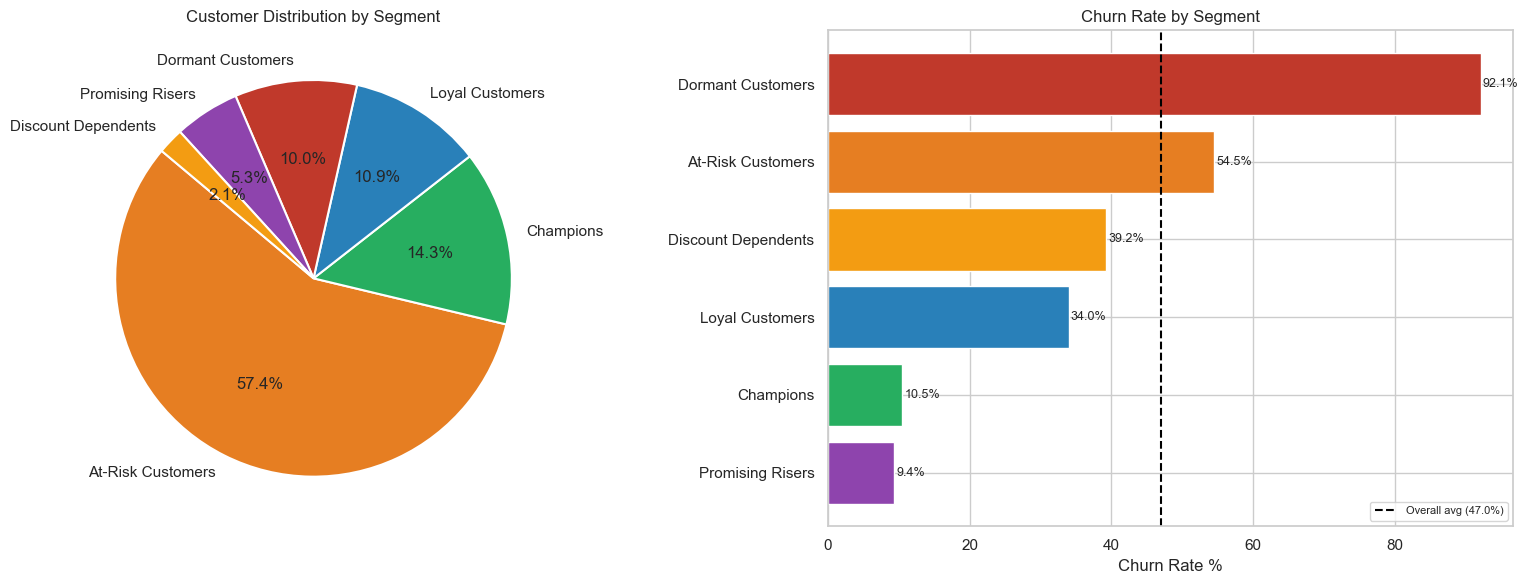

In [27]:
# Charts
seg_counts = rfm['segment'].value_counts()
fig, axes  = plt.subplots(1, 2, figsize=(16, 6))

colors = [SEG_COLORS[s] for s in seg_counts.index]
axes[0].pie(seg_counts.values, labels=seg_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Customer Distribution by Segment')

churn_by_seg = rfm.groupby('segment')['churn_next_60d'].mean().sort_values() * 100
bc           = [SEG_COLORS[s] for s in churn_by_seg.index]
bars = axes[1].barh(churn_by_seg.index, churn_by_seg.values, color=bc, edgecolor='white')
for bar, val in zip(bars, churn_by_seg.values):
    axes[1].text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
axes[1].axvline(rfm['churn_next_60d'].mean()*100, color='black', linestyle='--',
                label=f'Overall avg ({rfm["churn_next_60d"].mean()*100:.1f}%)')
axes[1].set_xlabel('Churn Rate %'); axes[1].set_title('Churn Rate by Segment'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_p2_02_segments_overview.png', dpi=120)
plt.show()

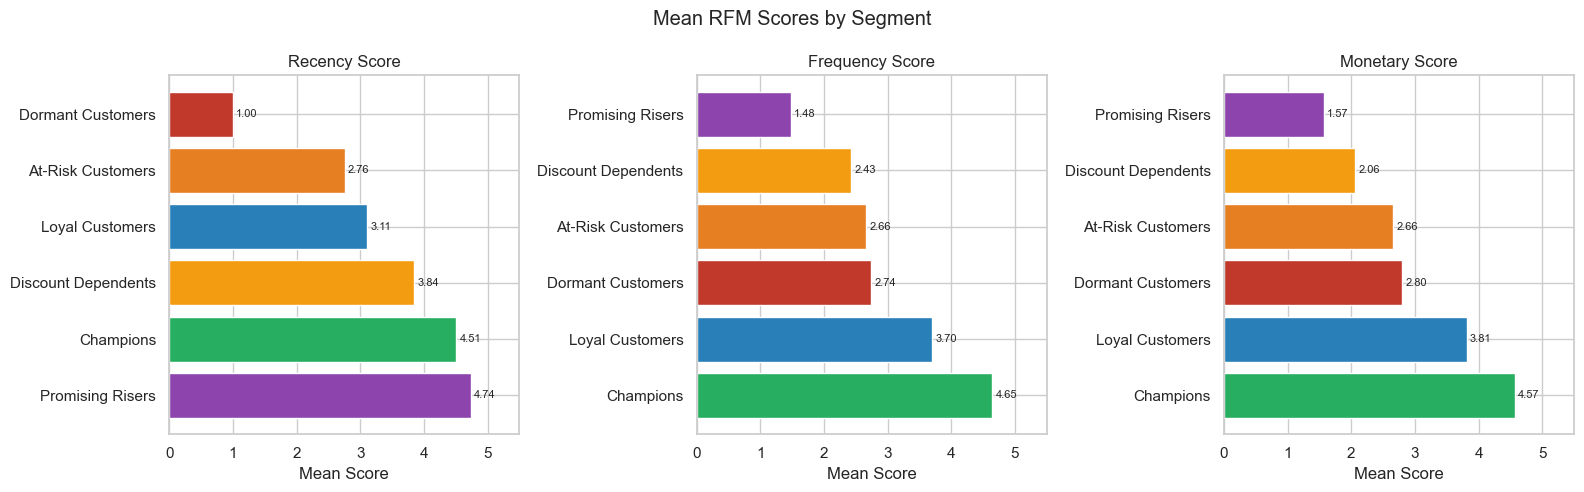

In [28]:
# RFM scores per segment
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, label in zip(axes,
                               ['R_score','F_score','M_score'],
                               ['Recency Score','Frequency Score','Monetary Score']):
    order = rfm.groupby('segment')[metric].mean().sort_values(ascending=False).index
    means = rfm.groupby('segment')[metric].mean().reindex(order)
    bar_c = [SEG_COLORS[s] for s in order]
    ax.barh(order, means.values, color=bar_c, edgecolor='white')
    ax.set_xlabel('Mean Score'); ax.set_title(label); ax.set_xlim(0, 5.5)
    for i, v in enumerate(means.values):
        ax.text(v+0.05, i, f'{v:.2f}', va='center', fontsize=8)
plt.suptitle('Mean RFM Scores by Segment')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_p2_03_rfm_scores.png', dpi=120)
plt.show()

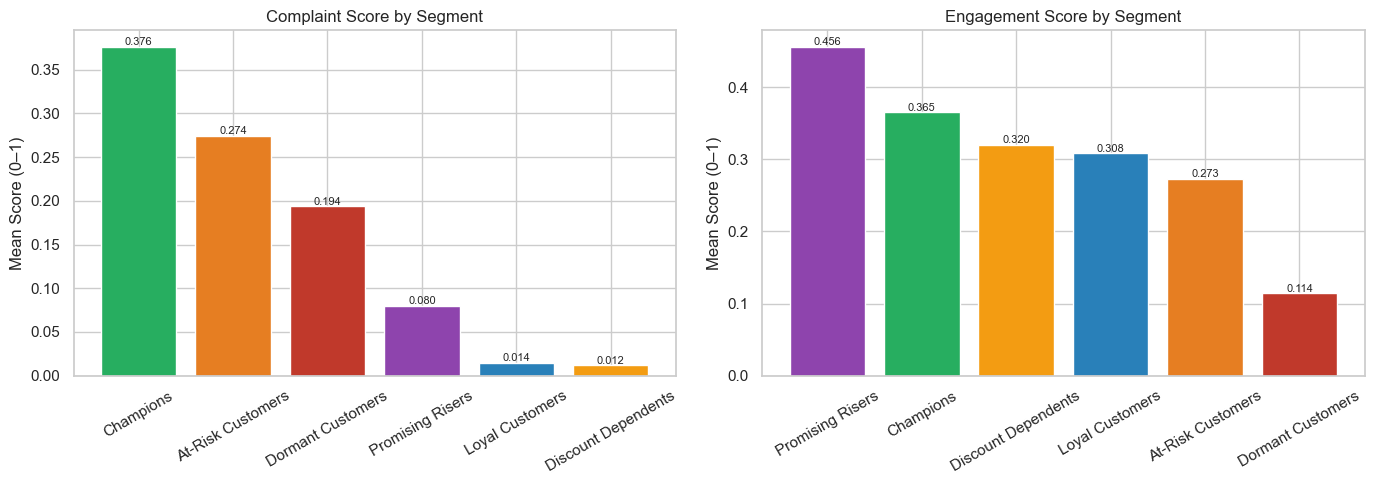

In [29]:
# Additional signals per segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes,
                               ['complaint_score','engagement_score'],
                               ['Complaint Score by Segment','Engagement Score by Segment']):
    order = rfm.groupby('segment')[metric].mean().sort_values(ascending=False).index
    means = rfm.groupby('segment')[metric].mean().reindex(order)
    bar_c = [SEG_COLORS[s] for s in order]
    ax.bar(order, means.values, color=bar_c, edgecolor='white')
    ax.set_title(title); ax.set_ylabel('Mean Score (0–1)'); ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(means.values):
        ax.text(i, v+0.002, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_p2_04_additional_signals.png', dpi=120)
plt.show()

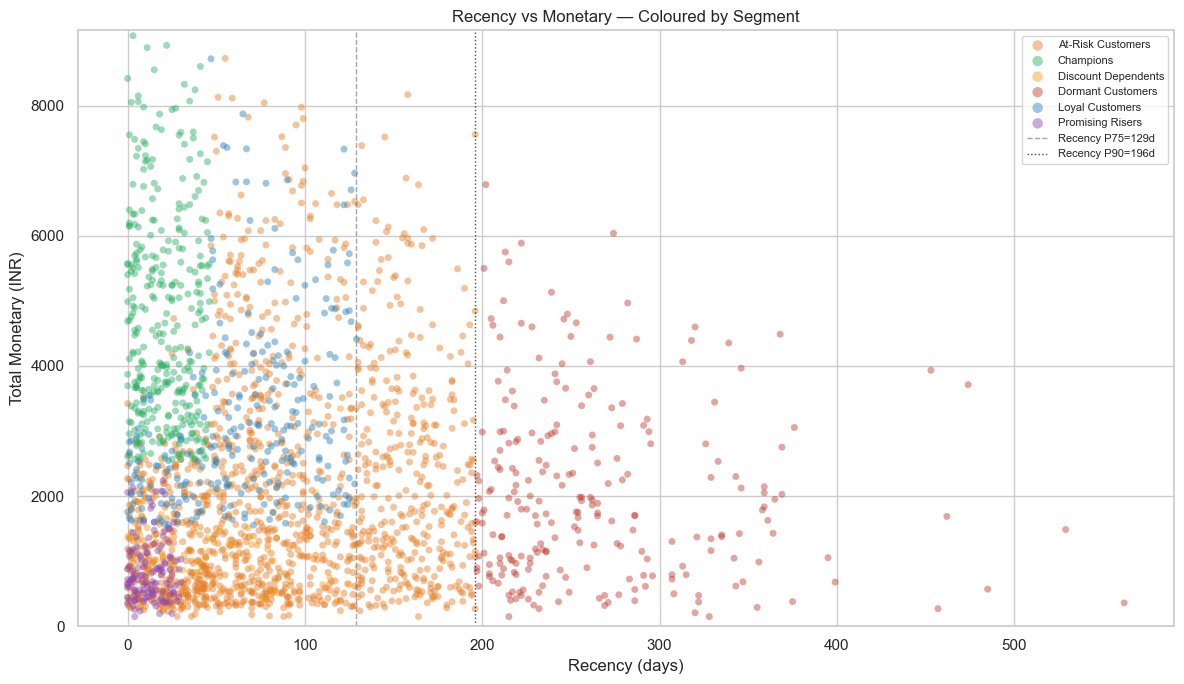

In [30]:
# Scatter: recency vs monetary coloured by segment
fig, ax = plt.subplots(figsize=(12, 7))
for seg, grp in rfm.groupby('segment'):
    ax.scatter(grp['recency_days'], grp['monetary'], c=SEG_COLORS[seg],
               label=seg, alpha=0.45, s=25, edgecolors='none')
ax.axvline(129, color='grey', linestyle='--', linewidth=1, alpha=0.7, label='Recency P75=129d')
ax.axvline(196, color='black', linestyle=':', linewidth=1, alpha=0.7, label='Recency P90=196d')
ax.set_xlabel('Recency (days)'); ax.set_ylabel('Total Monetary (INR)')
ax.set_title('Recency vs Monetary — Coloured by Segment')
ax.legend(loc='upper right', fontsize=8, markerscale=1.5)
ax.set_ylim(0, rfm['monetary'].quantile(0.99) * 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_p2_05_scatter.png', dpi=120)
plt.show()

## 5. Save segments.csv

In [31]:
out_cols = ['customer_id','segment','R_score','F_score','M_score','RFM_score',
            'recency_days','frequency','monetary','avg_discount','return_rate',
            'complaint_score','engagement_score','sessions_30d','last_visit_days_ago',
            'last_campaign_received','manual_priority_bucket','churn_next_60d','split']
rfm[out_cols].to_csv(OUTPUT_DIR / 'segments.csv', index=False)
print(f'Saved segments.csv — {len(rfm):,} rows')

Saved segments.csv — 2,400 rows


## 6. Budget Allocation & Retention Strategy

**Theory — Expected Value framework**  
Given a limited budget, maximise retention ROI:
> `Priority ∝ (churn_rate × avg_monetary × N_customers) / total_segment_cost`

Key principles:
- **Don't discount Champions** — they are already loyal; discounting trains them to wait for deals.
- **At-Risk is priority 1** — high churn rate, meaningful past spend, still recoverable.
- **Dormant** — low success rate; only target the top-LTV subset.
- **Discount Dependents** — reward with loyalty points, not more discounts.
- **Promising Risers** — cheap to convert into repeat buyers.

In [32]:
budget_plan = pd.DataFrame([
    {'priority':1,'segment':'At-Risk Customers',   'action':'Personalised email + 15% one-time coupon',
     'cost_per_cust':18,'budget_share_pct':35},
    {'priority':2,'segment':'Dormant Customers',    'action':'Win-back: new launch highlight + 20% discount (top-200 LTV only)',
     'cost_per_cust':30,'budget_share_pct':20},
    {'priority':3,'segment':'Promising Risers',     'action':'Free shipping on next order + loyalty enrolment prompt',
     'cost_per_cust':12,'budget_share_pct':20},
    {'priority':4,'segment':'Discount Dependents',  'action':'Loyalty points double-up + free sample (no direct discount)',
     'cost_per_cust':15,'budget_share_pct':15},
    {'priority':5,'segment':'Loyal Customers',      'action':'Tier upgrade notification + early product access',
     'cost_per_cust':8,'budget_share_pct':8},
    {'priority':6,'segment':'Champions',             'action':'Brand ambassador invite + thank-you reward',
     'cost_per_cust':5,'budget_share_pct':2},
])
budget_plan['allocated_INR'] = (budget_plan['budget_share_pct'] / 100 * TOTAL_BUDGET).astype(int)
budget_plan['est_customers'] = (budget_plan['allocated_INR'] / budget_plan['cost_per_cust']).astype(int)
display(budget_plan.set_index('priority'))

,segment,action,cost_per_cust,budget_share_pct,allocated_INR,est_customers
priority,,,,,,
1,At-Risk Customers,Personalised email + 15% one-time coupon,18,35,17500,972
2,Dormant Customers,Win-back: new launch highlight + 20% discount ...,30,20,10000,333
3,Promising Risers,Free shipping on next order + loyalty enrolmen...,12,20,10000,833
4,Discount Dependents,Loyalty points double-up + free sample (no dir...,15,15,7500,500
5,Loyal Customers,Tier upgrade notification + early product access,8,8,4000,500
6,Champions,Brand ambassador invite + thank-you reward,5,2,1000,200


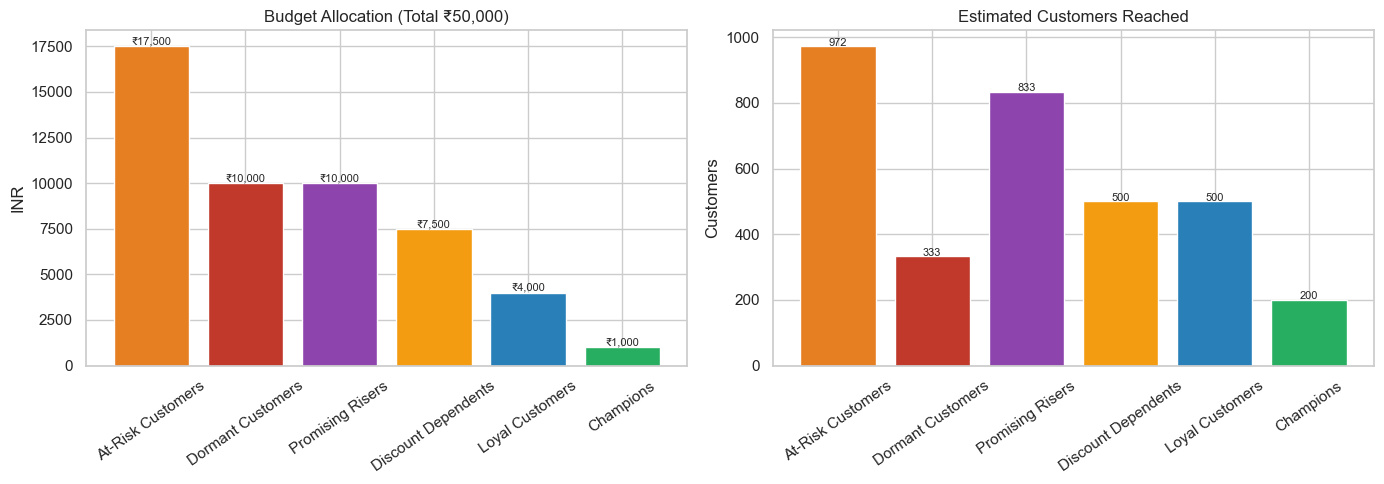

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bp_c = [SEG_COLORS[s] for s in budget_plan['segment']]
axes[0].bar(budget_plan['segment'], budget_plan['allocated_INR'], color=bp_c, edgecolor='white')
axes[0].set_title(f'Budget Allocation (Total ₹{TOTAL_BUDGET:,})')
axes[0].set_ylabel('INR'); axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(budget_plan['allocated_INR']):
    axes[0].text(i, v+100, f'₹{v:,}', ha='center', fontsize=8)
axes[1].bar(budget_plan['segment'], budget_plan['est_customers'], color=bp_c, edgecolor='white')
axes[1].set_title('Estimated Customers Reached'); axes[1].set_ylabel('Customers')
axes[1].tick_params(axis='x', rotation=35)
for i, v in enumerate(budget_plan['est_customers']):
    axes[1].text(i, v+2, str(v), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_p2_06_budget_allocation.png', dpi=120)
plt.show()

## 7. Manual Review — 10 Ambiguous Cases

**Theory — Why manual review is necessary**  
Rules draw hard boundaries. A customer with `recency_days=131` is At-Risk while one with `recency_days=129` is Loyal — despite being nearly identical. Five ambiguity types are covered:
1. Boundary straddle (just crossed a threshold)
2. Signal conflict (good RFM + bad support)
3. High LTV + high churn risk
4. Dormant but re-engaging now
5. Discount dependent but highly loyal

In [34]:
review_cols = ['customer_id','segment','recency_days','frequency','monetary',
               'avg_discount','return_rate','complaint_score','engagement_score',
               'sessions_30d','last_visit_days_ago','last_campaign_received',
               'manual_priority_bucket','churn_next_60d']

# Type 1: Boundary straddle — just At-Risk by recency, no complaints
t1 = rfm[(rfm.segment=='At-Risk Customers') & (rfm.recency_days>129) &
          (rfm.recency_days<145) & (rfm.complaint_score<0.05) & (rfm.frequency>=3)].head(2)
# Type 2: Champion-level RFM but high complaint
t2 = rfm[(rfm.RFM_score>=12) & (rfm.complaint_score>=0.20)].head(2)
# Type 3: High LTV + churned
t3 = rfm[(rfm.monetary > rfm.monetary.quantile(0.90)) &
          (rfm.churn_next_60d==1) & (rfm.segment=='At-Risk Customers')].head(2)
# Type 4: Dormant but re-engaging
t4 = rfm[(rfm.segment=='Dormant Customers') & (rfm.sessions_30d>=5) &
          (rfm.last_visit_days_ago<=7)].head(2)
# Type 5: Discount dependent but loyal
t5 = rfm[(rfm.segment=='Discount Dependents') & (rfm.frequency>=5) &
          (rfm.return_rate<0.1)].head(2)

manual = pd.concat([t1,t2,t3,t4,t5]).drop_duplicates('customer_id').head(10).reset_index(drop=True)

if len(manual) < 10:
    filler = rfm[~rfm.customer_id.isin(manual.customer_id)].sort_values('RFM_score').head(10-len(manual))
    manual = pd.concat([manual, filler[review_cols]]).reset_index(drop=True)

print(f'Selected {len(manual)} manual review cases')
display(manual[review_cols])

Selected 10 manual review cases


,customer_id,segment,recency_days,frequency,monetary,avg_discount,return_rate,complaint_score,engagement_score,sessions_30d,last_visit_days_ago,last_campaign_received,manual_priority_bucket,churn_next_60d
0,CUST00116,At-Risk Customers,143,6,5635.90,0.19,0.00,0.00,0.35,10,26,new_launch,high,1
1,CUST00296,At-Risk Customers,132,4,1989.83,0.20,0.00,0.00,0.14,2,30,none,high,1
2,CUST00014,At-Risk Customers,51,11,8130.16,0.26,0.00,0.33,0.35,11,17,bundle_discount,medium,0
3,CUST00030,Champions,5,6,3435.59,0.34,0.00,0.53,0.38,11,3,free_shipping,medium,0
4,CUST00088,At-Risk Customers,98,12,6774.50,0.36,0.00,0.67,0.31,9,18,new_launch,high,1
5,CUST01657,Dormant Customers,328,1,149.00,0.39,0.00,0.00,0.06,2,60,new_launch,high,1
6,CUST01606,At-Risk Customers,180,1,282.09,0.45,0.00,0.47,0.09,1,36,none,high,1
7,CUST01649,Dormant Customers,243,1,376.88,0.21,0.00,0.00,0.03,1,56,bundle_discount,high,1
8,CUST01648,At-Risk Customers,150,1,540.77,0.19,0.00,0.00,0.30,2,23,welcome_offer,high,0
9,CUST00047,Dormant Customers,204,1,764.43,0.16,0.00,0.00,0.18,2,36,free_shipping,high,1


In [35]:
def generate_reasoning(row):
    lines = [
        f"### {row['customer_id']} | Segment: {row['segment']} | CRM: {row['manual_priority_bucket']} | Actual churn: {int(row['churn_next_60d']) if pd.notna(row['churn_next_60d']) else 'unknown'}",
        f"- RFM: recency={row['recency_days']:.0f}d, freq={row['frequency']:.0f}, monetary=₹{row['monetary']:,.0f}",
        f"- Signals: discount={row['avg_discount']:.2f}, complaint={row['complaint_score']:.3f}, engagement={row['engagement_score']:.3f}, sessions={row['sessions_30d']:.0f}, last_visit={row['last_visit_days_ago']:.0f}d",
        f"- Last campaign: {row['last_campaign_received']}",
    ]
    seg, rec, freq, mon = row['segment'], row['recency_days'], row['frequency'], row['monetary']
    comp, eng, sess, vis = row['complaint_score'], row['engagement_score'], row['sessions_30d'], row['last_visit_days_ago']

    if seg == 'At-Risk Customers' and rec <= 145 and comp < 0.05 and freq >= 3:
        advice = 'Boundary straddle — crossed At-Risk by recency only, no complaint history. Send soft re-engagement email; monitor 30 days before escalating spend.'
    elif comp >= 0.20 and row['RFM_score'] >= 12:
        advice = 'Signal conflict — high RFM but significant complaints. Service-recovery message first (apology + account review); no promotion until satisfaction is confirmed.'
    elif mon > 5000 and row.get('churn_next_60d', 0) == 1:
        advice = 'High-LTV churned customer — immediate personal outreach (WhatsApp/phone), not just email. Offer exclusive SKU or bundle, not a generic discount.'
    elif seg == 'Dormant Customers' and sess >= 5 and vis <= 7:
        advice = 'Dormant but re-engaging NOW — treat as Promising Riser; send a welcome-back offer while intent is hot.'
    elif seg == 'Discount Dependents' and freq >= 5 and row.get('return_rate', 1) < 0.1:
        advice = 'Loyal discount buyer — trial loyalty-points reward instead of coupons for 2 campaigns; measure if purchase frequency holds.'
    else:
        advice = 'Mixed signals near multiple boundaries — apply action of closest segment; flag for CRM review after next interaction.'

    lines.append(f'**Recommendation:** {advice}')
    return '\n'.join(lines)

for _, row in manual.iterrows():
    print(generate_reasoning(row))
    print()

### CUST00116 | Segment: At-Risk Customers | CRM: high | Actual churn: 1
- RFM: recency=143d, freq=6, monetary=₹5,636
- Signals: discount=0.19, complaint=0.000, engagement=0.349, sessions=10, last_visit=26d
- Last campaign: new_launch
**Recommendation:** Boundary straddle — crossed At-Risk by recency only, no complaint history. Send soft re-engagement email; monitor 30 days before escalating spend.

### CUST00296 | Segment: At-Risk Customers | CRM: high | Actual churn: 1
- RFM: recency=132d, freq=4, monetary=₹1,990
- Signals: discount=0.20, complaint=0.000, engagement=0.145, sessions=2, last_visit=30d
- Last campaign: none
**Recommendation:** Boundary straddle — crossed At-Risk by recency only, no complaint history. Send soft re-engagement email; monitor 30 days before escalating spend.

### CUST00014 | Segment: At-Risk Customers | CRM: medium | Actual churn: 0
- RFM: recency=51d, freq=11, monetary=₹8,130
- Signals: discount=0.26, complaint=0.333, engagement=0.347, sessions=11, last_vi

## 8. Save Markdown Files

In [36]:
strategy_md = f"""# Retention Strategy
Snapshot date: 2025-09-30 | Total budget: ₹{TOTAL_BUDGET:,}

## Segmentation Logic
Six segments defined using RFM quintile scores plus two composite signals:
- complaint_score = 40% ticket_count_norm + 40% neg_ticket_rate + 20% pct_reopened
- engagement_score = 35% sessions + 20% cart_adds + 20% visit_recency_inv + 15% email_opens + 10% campaign_clicks
Thresholds from actual data quantiles: recency P75=129d, P90=196d; frequency P25=1, P75=5.

## Retention Actions
| Priority | Segment | Action | Cost/Customer |
|---|---|---|---|
| 1 | At-Risk | Personalised email + 15% one-time coupon | ₹18 |
| 2 | Dormant | Win-back: new launch + 20% discount (top-LTV only) | ₹30 |
| 3 | Promising Risers | Free shipping + loyalty enrolment prompt | ₹12 |
| 4 | Discount Dependents | Loyalty points double-up + free sample | ₹15 |
| 5 | Loyal | Tier upgrade notification + early access | ₹8 |
| 6 | Champions | Ambassador invite + thank-you reward | ₹5 |

## Budget Breakdown
| Segment | Budget Share | Allocated | Est. Reach |
|---|---|---|---|
| At-Risk | 35% | ₹17,500 | ~972 |
| Dormant | 20% | ₹10,000 | ~333 |
| Promising Risers | 20% | ₹10,000 | ~833 |
| Discount Dependents | 15% | ₹7,500 | ~500 |
| Loyal | 8% | ₹4,000 | ~500 |
| Champions | 2% | ₹1,000 | ~200 |

## Why At-Risk is Priority 1
1. Highest churn rate among recoverable segments.
2. Meaningful historical monetary value — each saved customer is material LTV.
3. Still within recovery window (Dormant customers have already disengaged psychologically).
4. Lower intervention cost (₹18) than Dormant (₹30).

## What NOT to Do
- Do not blanket-discount Champions or Loyal — trains them to wait for deals.
- Do not run broad Dormant win-back — filter to top-LTV only; math does not support wide spend.
- Always measure incremental lift against a holdout group per segment.
"""

with open(OUTPUT_DIR / 'retention_strategy.md', 'w') as f:
    f.write(strategy_md)
print('Saved retention_strategy.md')

Saved retention_strategy.md


In [37]:
review_header = """# Manual Review Cases — Part 2
10 customers selected at segment decision boundaries or where signals conflict.
Five ambiguity types: boundary straddle, signal conflict, high-LTV churn, dormant-re-engaging, loyal discount buyer.

---

"""
review_body = ''
for _, row in manual.iterrows():
    review_body += generate_reasoning(row) + '\n\n---\n\n'

with open(OUTPUT_DIR / 'manual_review_cases.md', 'w') as f:
    f.write(review_header + review_body)
print('Saved manual_review_cases.md')
print('\nPart 2 complete. All outputs in outputs/')

Saved manual_review_cases.md

Part 2 complete. All outputs in outputs/
